### Obliczanie fft - przykład

In [125]:
import numpy as np
import matplotlib.pyplot as plt

##### Przykładowy sygnał

In [128]:
#parametry sygnału
fs = 1000   # częstotliwość próbkowania (Hz)
To = 1      # czas trwania (sekundy)
N = fs * To # liczba próbek

t = np.linspace(0, To, N, endpoint=False)

# składowe sygnału
dc = 2.0
f1 = 5
f2 = 20

signal = (dc
          + 1.5 * np.sin(2 * np.pi * f1 * t)
          + 0.7 * np.sin(2 * np.pi * f2 * t)
          + 0.5 * np.random.randn(N))  # szum

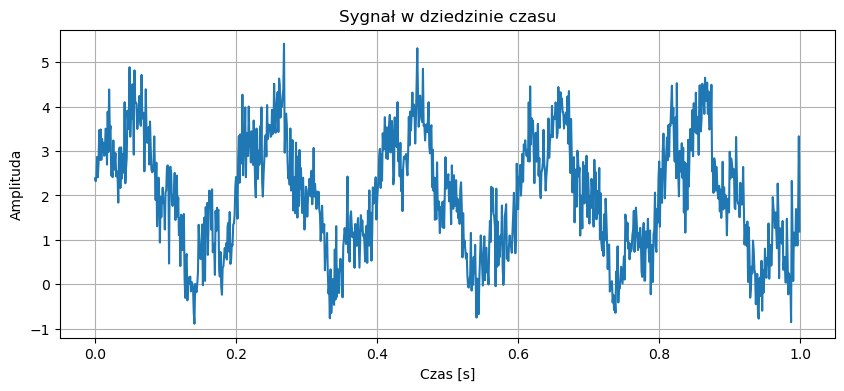

In [130]:
plt.figure(figsize=(10,4))
plt.plot(t, signal)
plt.title("Sygnał w dziedzinie czasu")
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda")
plt.grid()
plt.show()

### **FFT z numpy**
$X(k) = \sum_{n=0}^{N-1} x(n) \cdot e^{-j \frac{2\pi}{N} k n}$

In [133]:
X = np.fft.fft(signal)

In [135]:
#moduł 
Xamp = np.abs(X)

#### 1. Obliczenie częstotliwości
$f_k = \frac{k}{N} f_s$

In [138]:
freqs = np.fft.fftfreq(N, d=1/fs)

#### 2. Połowa widma

In [141]:
half = N // 2

X_half = Xamp[:half]
freqs_half = freqs[:half]

#### 3. Normalizacja widma

In [144]:
Xamp = 2 * X_half / N

Xamp[0] = Xamp[0] / 2  #nie mnożymy przez 2 skąłdowej stałej

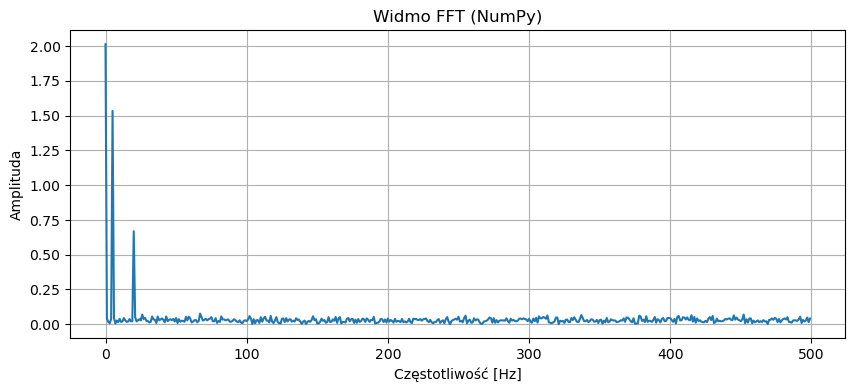

In [150]:
plt.figure(figsize=(10,4))
plt.plot(freqs_half, Xamp)
plt.title("Widmo FFT (NumPy)")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
plt.grid()
plt.show()

In [88]:
#5 najwyższych częstotliwości
idx = np.argsort(Xamp)[::-1][:5]
print(freqs_half[idx])

[  0.   5.  20. 244.  62.]


### **FFT z scipy**

In [91]:
from scipy.fft import fft, fftfreq

In [97]:
#widmo
X = fft(signal)

In [99]:
#obliczenie częstotliwości
freqs = fftfreq(N, d=1/fs)

In [105]:
#połowa widma
half = N // 2

X_half = X[:half]
freqs_half = freqs[:half]

In [109]:
#widmo amplitudowe
amplitude = np.abs(X_half)

In [111]:
#normalizacja
amplitude = (2.0 / N) * amplitude
amplitude[0] /= 2   # poprawka dla DC

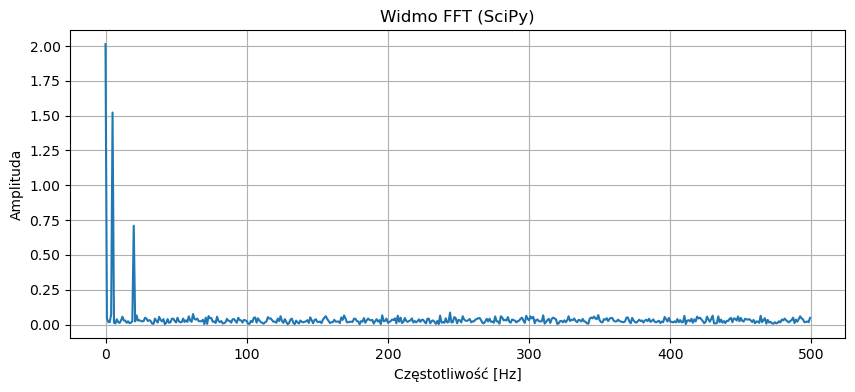

In [115]:
#wizualizacja
plt.figure(figsize=(10,4))
plt.plot(freqs_half, amplitude)
plt.title("Widmo FFT (SciPy)")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("Amplituda")
plt.grid()
plt.show()

In [117]:
#znalezienie głównych częstotliwości
idx = np.argsort(amplitude)[::-1][:5]
print(freqs_half[idx])

[  0.   5.  20. 244.  62.]


#### Bonus: tylko dodatnie częstotliwości z scipy

In [120]:
from scipy.fft import rfft, rfftfreq

X = rfft(signal)
freqs = rfftfreq(N, d=1/fs)

amplitude = (2.0 / N) * np.abs(X)
amplitude[0] /= 2